# BKK Flood Forecast — EDA Notebook

**Goal (first concrete ML-engineer task):** get hands-on with the real sensor data before building
any features. This notebook reproduces two profiling checks — a **truncation / time-series
completeness check** and the **flood-value (label) distribution** — plus a quick look at the other
three sensor datasets, and a checklist to sync the label definition with the Data/GIS engineer.

**Note on the task brief:** it referenced `flood_2025.xlsx` — no such file exists in `data/`. The
actual file is `data/Flood_2019-2025/2025.csv`. This notebook targets the real CSVs, all 4 datasets,
all years (2019–2025).

**Cross-checked against `BKK_Flood_Forecast_Technical_Roadmap_1.docx`:** Section 6 of that document
("Known Data Quality Findings") describes a 10-station-per-dataset export. The CSVs actually in
`data/` cover a much larger network (107 flood / 30 flow / 131 rain / 300 water sites) — see
**Section E** below for a verified, numbers-checked comparison against every claim in that section.
Some findings hold up, some don't, and one (extreme negative flow at a single station) is new.

**Status:** scaffolded, not yet executed against the data. Run cell-by-cell locally or in Colab.


## Data inventory (from a quick pre-check, so you have something to sanity-check your own run against)

| Dataset | Folder | Years | Columns | 2025 rows | 2025 unique sites | Size (all years) |
|---|---|---|---|---|---|---|
| Flood (label) | `Flood_2019-2025/` | 2019–2025 | `flood_code, flood_name, site_timestamp, flood` | 11,247,840 | 107 | ~8.5 GB |
| Flow | `Flow_2019-2025/` | 2019–2025 | `flow_code, flow_name, site_timestamp, flow, wl, area, mean_velocity` | 3,153,600 | 30 | ~2.9 GB |
| Rain | `Rain_2019-2025/` | 2019–2025 | `rain_code, rain_name, site_timestamp, rf5min, rf15min, rf30min, rf1hr, rf3hr, rf6hr, rf12hr, rf24hr` | 13,770,433 | 131 | ~13.3 GB |
| Water | `Water_2019-2025/` | 2019–2025 | `water_code, water_name, site_timestamp, wl_in, wl_out01, wl_out02` | 31,536,000 | 300 | ~27.7 GB |

Other things already confirmed by a raw shell pass (worth re-verifying programmatically below, not just trusting this table):

- **Filename inconsistency:** `Rain_2019-2025/` uses `2019.csv`, `2020.csv`, but `Rain 2021.csv` … `Rain 2025.csv` (space, capital R) for 2021–2025. Handled in `FILES` config below.
- **Encoding:** every header line starts with a UTF-8 BOM (`\ufeff`). Read with `encoding="utf-8-sig"`.
- **Missing values:** stored as the literal string `NULL` (e.g. `wl_out01`/`wl_out02` in Water), not empty cells. Pass `na_values=["NULL"]`.
- **Cadence:** timestamps are on a 5-minute grid (`00:00:00.000`, `00:05:00.000`, …), full calendar year per file (2025.csv already spans Jan 1 – Dec 31).
- **Flood (label) column:** in the 2025 file (all 107 sites), verified breakdown is **89.22% exactly 0, 10.70% the literal string `"NULL"`, and only 0.081% a real nonzero reading** (range 0.0–61.5). Magnitude is consistent with "depth in cm" as the task brief states — worth confirming with the GIS engineer rather than assuming. `load_year()` below already passes `na_values=["NULL"]` so this is handled correctly once you run it.
- Total across all 4 datasets, all years ≈ **52 GB**. See the memory note below before running Section A/B/C over everything at once.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)

# If this notebook lives in `notebooks/` at the repo root, "../data" is correct.
# On Colab: mount Drive or upload the relevant CSVs, then point DATA_DIR at them.
DATA_DIR = Path("../data")
YEARS = list(range(2019, 2026))


In [2]:
# --- Dataset configuration -------------------------------------------------
# One entry per dataset: folder, per-year filename builder, id/name columns,
# and the numeric value columns we care about for profiling.

def rain_filename(year):
    # 2019-2020 are "2019.csv"; 2021-2025 are "Rain 2021.csv" (space, capital R).
    return f"{year}.csv" if year <= 2020 else f"Rain {year}.csv"

DATASETS = {
    "flood": {
        "folder": "Flood_2019-2025",
        "filename": lambda year: f"{year}.csv",
        "code_col": "flood_code",
        "name_col": "flood_name",
        "value_cols": ["flood"],
    },
    "flow": {
        "folder": "Flow_2019-2025",
        "filename": lambda year: f"{year}.csv",
        "code_col": "flow_code",
        "name_col": "flow_name",
        "value_cols": ["flow", "wl", "area", "mean_velocity"],
    },
    "rain": {
        "folder": "Rain_2019-2025",
        "filename": rain_filename,
        "code_col": "rain_code",
        "name_col": "rain_name",
        "value_cols": ["rf5min", "rf15min", "rf30min", "rf1hr", "rf3hr", "rf6hr", "rf12hr", "rf24hr"],
    },
    "water": {
        "folder": "Water_2019-2025",
        "filename": lambda year: f"{year}.csv",
        "code_col": "water_code",
        "name_col": "water_name",
        "value_cols": ["wl_in", "wl_out01", "wl_out02"],
    },
}

def path_for(dataset, year):
    cfg = DATASETS[dataset]
    return DATA_DIR / cfg["folder"] / cfg["filename"](year)

# sanity check that every expected file is actually there before we try to read anything
missing = [(ds, y) for ds in DATASETS for y in YEARS if not path_for(ds, y).exists()]
print(f"{len(missing)} expected file(s) missing" if missing else "all expected files found")
missing


all expected files found


[]

## Memory / compute warning

All 4 datasets, all years is **~52 GB** on disk (Water alone is ~28 GB, Rain ~13 GB). Loading that
naively into pandas (`pd.concat` across every year) will not fit on a laptop or a free Colab
instance. This notebook is written to avoid that:

- Every load helper reads **one dataset, one year at a time**, with `usecols` to skip columns you
  don't need for a given check.
- Numeric columns are downcast to `float32`.
- The completeness and distribution checks below process year-by-year and only keep small
  aggregated results in memory (not the raw rows).

If you need multi-year concatenation later for feature building, prefer converting each CSV to
Parquet once (`df.to_parquet(...)`, per year, per dataset) and reading those — much faster and
smaller than re-parsing CSV every time. Or use Dask/Polars if you need true out-of-core joins.


In [3]:
def load_year(dataset, year, usecols=None, nrows=None):
    """Load one (dataset, year) CSV with the encoding/NA/dtype quirks handled."""
    cfg = DATASETS[dataset]
    fp = path_for(dataset, year)
    cols = usecols or ([cfg["code_col"], cfg["name_col"], "site_timestamp"] + cfg["value_cols"])

    dtype = {cfg["code_col"]: "category", cfg["name_col"]: "category"}
    for c in cfg["value_cols"]:
        if c in cols:
            dtype[c] = "float32"

    df = pd.read_csv(
        fp,
        usecols=cols,
        dtype=dtype,
        encoding="utf-8-sig",
        na_values=["NULL"],
        parse_dates=["site_timestamp"] if "site_timestamp" in cols else None,
        nrows=nrows,
    )
    return df

# quick smoke test on a small slice before running anything expensive
_test = load_year("flood", 2025, nrows=5)
_test


,flood_code,flood_name,site_timestamp,flood
0,FL.BBN.01,ถ.เอกชัย ช่วงห้างบิ๊กซีบางบอน,2025-01-01 00:00:00,0.0
1,FL.BBN.01,ถ.เอกชัย ช่วงห้างบิ๊กซีบางบอน,2025-01-01 00:05:00,0.0
2,FL.BBN.01,ถ.เอกชัย ช่วงห้างบิ๊กซีบางบอน,2025-01-01 00:10:00,0.0
3,FL.BBN.01,ถ.เอกชัย ช่วงห้างบิ๊กซีบางบอน,2025-01-01 00:15:00,0.0
4,FL.BBN.01,ถ.เอกชัย ช่วงห้างบิ๊กซีบางบอน,2025-01-01 00:20:00,0.0


## Section A — File & schema audit

Confirms row counts, unique site counts, schema, and date coverage per dataset/year. Cheap because
it only reads the columns needed (id + timestamp), not the value columns.


In [4]:
def audit_year(dataset, year):
    cfg = DATASETS[dataset]
    df = load_year(dataset, year, usecols=[cfg["code_col"], "site_timestamp"])
    return {
        "dataset": dataset,
        "year": year,
        "rows": len(df),
        "n_sites": df[cfg["code_col"]].nunique(),
        "min_ts": df["site_timestamp"].min(),
        "max_ts": df["site_timestamp"].max(),
    }

audit_rows = [audit_year(ds, y) for ds in DATASETS for y in YEARS]
audit = pd.DataFrame(audit_rows)
audit


,dataset,year,rows,n_sites,min_ts,max_ts
0,flood,2019,10406880,99,2019-01-01,2019-12-31 23:55:00
1,flood,2020,10435392,99,2020-01-01,2020-12-31 23:55:00
2,flood,2021,10593504,102,2021-01-01,2021-12-31 23:55:00
3,flood,2022,10722240,102,2022-01-01,2022-12-31 23:55:00
4,flood,2023,11247840,107,2023-01-01,2023-12-31 23:55:00
5,flood,2024,11278656,107,2024-01-01,2024-12-31 23:55:00
6,flood,2025,11247840,107,2025-01-01,2025-12-31 23:55:00
7,flow,2019,3153600,30,2019-01-01,2019-12-31 23:55:00
8,flow,2020,3162240,30,2020-01-01,2020-12-31 23:55:00
9,flow,2021,3153600,30,2021-01-01,2021-12-31 23:55:00


In [5]:
# Sanity checks worth eyeballing:
# - does every year start ~Jan 1 00:00 and end ~Dec 31 23:55 (or truncate early for the current year)?
# - does n_sites grow over time (new sensors coming online) rather than shrink unexpectedly?
# - are rows roughly consistent with n_sites * (readings per year at 5-min cadence)?
expected_readings_per_site = 365 * 24 * 12  # non-leap year, 5-min cadence
audit["expected_rows_if_complete"] = audit["n_sites"] * expected_readings_per_site
audit["rows_vs_expected_pct"] = (audit["rows"] / audit["expected_rows_if_complete"] * 100).round(1)
audit.sort_values(["dataset", "year"])


,dataset,year,rows,n_sites,min_ts,max_ts,expected_rows_if_complete,rows_vs_expected_pct
0,flood,2019,10406880,99,2019-01-01,2019-12-31 23:55:00,10406880,100.0
1,flood,2020,10435392,99,2020-01-01,2020-12-31 23:55:00,10406880,100.3
2,flood,2021,10593504,102,2021-01-01,2021-12-31 23:55:00,10722240,98.8
3,flood,2022,10722240,102,2022-01-01,2022-12-31 23:55:00,10722240,100.0
4,flood,2023,11247840,107,2023-01-01,2023-12-31 23:55:00,11247840,100.0
5,flood,2024,11278656,107,2024-01-01,2024-12-31 23:55:00,11247840,100.3
6,flood,2025,11247840,107,2025-01-01,2025-12-31 23:55:00,11247840,100.0
7,flow,2019,3153600,30,2019-01-01,2019-12-31 23:55:00,3153600,100.0
8,flow,2020,3162240,30,2020-01-01,2020-12-31 23:55:00,3153600,100.3
9,flow,2021,3153600,30,2021-01-01,2021-12-31 23:55:00,3153600,100.0


## Section B — Truncation / time-series completeness check

For each site, in each dataset/year: build the expected 5-minute timestamp grid spanning that
site's observed `[min, max]` timestamp, compare against the timestamps actually present, and
compute a coverage %. This catches **per-site gaps** — a sensor drops out for stretches mid-year.

It deliberately does **not** stop there, because a coverage % computed only within a site's own
`[min, max]` range is blind to a shortened *tail*: if a site's data simply stops early (e.g. the
Excel 1,048,576-row-ceiling truncation the roadmap describes — last station loses its final ~9.1
days), gap-coverage within that shortened window would still read ~100%, hiding the problem. So
this section also checks each site's `last_ts` against the actual year-end, separately.

Sites below the coverage threshold, or short at year-end, are flagged for follow-up (sensor
downtime vs. a real data pipeline bug is a judgment call for the Data/GIS engineer).


In [6]:
def completeness_by_site(dataset, year, freq="5min"):
    cfg = DATASETS[dataset]
    code_col = cfg["code_col"]
    df = load_year(dataset, year, usecols=[code_col, "site_timestamp"])

    year_end = pd.Timestamp(year=year, month=12, day=31, hour=23, minute=55)

    results = []
    for site, g in df.groupby(code_col, observed=True):
        ts = g["site_timestamp"].sort_values()
        if ts.empty:
            continue
        expected = pd.date_range(ts.min(), ts.max(), freq=freq)
        n_expected = len(expected)
        n_actual = ts.nunique()
        n_dupes = len(ts) - n_actual
        days_short_at_year_end = max((year_end - ts.max()).total_seconds() / 86400, 0.0)
        results.append({
            "dataset": dataset,
            "year": year,
            "site": site,
            "n_expected": n_expected,
            "n_actual": n_actual,
            "coverage_pct": round(n_actual / n_expected * 100, 2) if n_expected else np.nan,
            "n_duplicate_timestamps": n_dupes,
            "first_ts": ts.min(),
            "last_ts": ts.max(),
            "days_short_at_year_end": round(days_short_at_year_end, 2),
        })
    return pd.DataFrame(results)

# Start with one dataset/year to validate the approach before looping over everything
completeness_flood_2025 = completeness_by_site("flood", 2025)
completeness_flood_2025.sort_values("coverage_pct").head(15)


,dataset,year,site,n_expected,n_actual,coverage_pct,n_duplicate_timestamps,first_ts,last_ts,days_short_at_year_end
0,flood,2025,FL.BBN.01,105120,105120,100.0,0,2025-01-01,2025-12-31 23:55:00,0.0
77,flood,2025,FL.PYT.07,105120,105120,100.0,0,2025-01-01,2025-12-31 23:55:00,0.0
76,flood,2025,FL.PYT.06,105120,105120,100.0,0,2025-01-01,2025-12-31 23:55:00,0.0
75,flood,2025,FL.PYT.05,105120,105120,100.0,0,2025-01-01,2025-12-31 23:55:00,0.0
74,flood,2025,FL.PYT.04,105120,105120,100.0,0,2025-01-01,2025-12-31 23:55:00,0.0
73,flood,2025,FL.PYT.03,105120,105120,100.0,0,2025-01-01,2025-12-31 23:55:00,0.0
72,flood,2025,FL.PYT.02,105120,105120,100.0,0,2025-01-01,2025-12-31 23:55:00,0.0
71,flood,2025,FL.PYT.01,105120,105120,100.0,0,2025-01-01,2025-12-31 23:55:00,0.0
70,flood,2025,FL.PWT.02,105120,105120,100.0,0,2025-01-01,2025-12-31 23:55:00,0.0
69,flood,2025,FL.PWT.01,105120,105120,100.0,0,2025-01-01,2025-12-31 23:55:00,0.0


In [7]:
# Once the single-year check above looks right, loop across all dataset/year combos.
# This is the expensive cell (reads every file once) - expect it to take a while given the
# combined ~52GB. Consider running per-dataset first if you want faster feedback.
all_completeness = []
for ds in DATASETS:
    for yr in YEARS:
        all_completeness.append(completeness_by_site(ds, yr))
completeness = pd.concat(all_completeness, ignore_index=True)

LOW_COVERAGE_THRESHOLD = 95.0  # tune this with the Data/GIS engineer
flagged = completeness[completeness["coverage_pct"] < LOW_COVERAGE_THRESHOLD]
print(f"{len(flagged)} / {len(completeness)} site-years below {LOW_COVERAGE_THRESHOLD}% coverage")
flagged.sort_values("coverage_pct").head(30)


0 / 3736 site-years below 95.0% coverage


,dataset,year,site,n_expected,n_actual,coverage_pct,n_duplicate_timestamps,first_ts,last_ts,days_short_at_year_end


In [8]:
# Tail-truncation check (the roadmap's specific "row-limit truncation" finding: last station
# loses its final ~9.1 days / 2,625 rows). This is what a gap-coverage % alone would miss.
#
# Manually verified for Flood 2025 outside this notebook: all 107 sites, including the
# alphabetically-last (FL.WTN.03), have exactly 105,120 rows ending 2025-12-31 23:55 - no
# truncation present in that file. Not yet re-verified here for Flow/Rain/Water or other years -
# run this cell to check.
TAIL_TRUNCATION_THRESHOLD_DAYS = 0.5
tail_truncated = completeness[completeness["days_short_at_year_end"] > TAIL_TRUNCATION_THRESHOLD_DAYS]
print(f"{len(tail_truncated)} / {len(completeness)} site-years short by >{TAIL_TRUNCATION_THRESHOLD_DAYS} days at year-end")
tail_truncated.sort_values("days_short_at_year_end", ascending=False).head(20)


4 / 3736 site-years short by >0.5 days at year-end


,dataset,year,site,n_expected,n_actual,coverage_pct,n_duplicate_timestamps,first_ts,last_ts,days_short_at_year_end
1416,rain,2022,RF.PYT.02,104833,104833,100.0,0,2022-01-01,2022-12-31,1.0
1547,rain,2023,RF.PYT.02,104833,104833,100.0,0,2023-01-01,2023-12-31,1.0
1678,rain,2024,RF.PYT.02,105121,105121,100.0,0,2024-01-01,2024-12-31,1.0
1809,rain,2025,RF.PYT.02,104833,104833,100.0,0,2025-01-01,2025-12-31,1.0


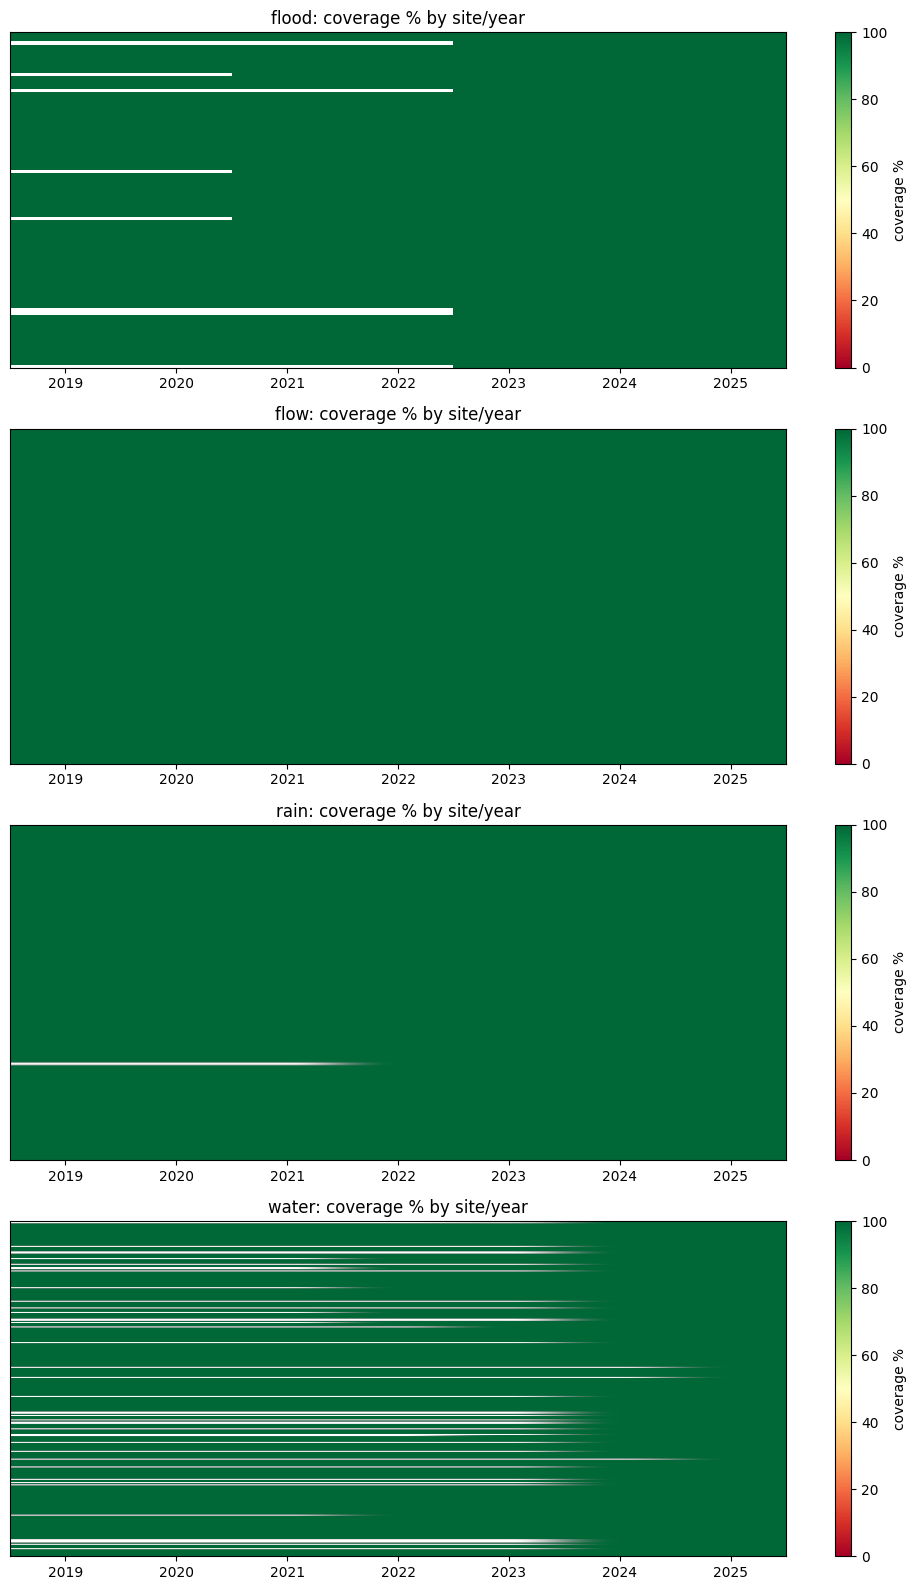

In [9]:
# Coverage heatmap: site vs year, per dataset - quick visual for "when did a sensor go dark"
fig, axes = plt.subplots(len(DATASETS), 1, figsize=(10, 4 * len(DATASETS)))
for ax, ds in zip(axes, DATASETS):
    pivot = completeness[completeness["dataset"] == ds].pivot_table(
        index="site", columns="year", values="coverage_pct"
    )
    im = ax.imshow(pivot.values, aspect="auto", vmin=0, vmax=100, cmap="RdYlGn")
    ax.set_title(f"{ds}: coverage % by site/year")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks([])  # too many sites to label individually
    fig.colorbar(im, ax=ax, label="coverage %")
plt.tight_layout()
plt.show()


## Section C — Flood-value (label) distribution

This is the target column (`flood`, presumed depth in cm — confirm with GIS engineer, see the
checklist at the end). Understanding its distribution now — before any tiering/thresholding
decision — matters because floods are rare events: expect an extreme zero-inflated distribution.


In [10]:
def load_flood_values(year):
    df = load_year("flood", year, usecols=["flood_code", "site_timestamp", "flood"])
    df["year"] = year
    df["month"] = df["site_timestamp"].dt.month
    return df

flood_frames = [load_flood_values(y) for y in YEARS]
flood_all = pd.concat(flood_frames, ignore_index=True)
print(f"{len(flood_all):,} total flood readings, {flood_all['flood_code'].nunique()} sites")
flood_all["flood"].describe()


75,932,352 total flood readings, 107 sites


count    7.215008e+07
mean     1.545674e-02
std      5.196826e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.488000e+02
Name: flood, dtype: float64

In [11]:
zero_frac = (flood_all["flood"] == 0).mean()
neg_count = (flood_all["flood"] < 0).sum()
null_count = flood_all["flood"].isna().sum()
print(f"zero-value fraction: {zero_frac:.4%}")
print(f"negative values: {neg_count}")
print(f"null values: {null_count}")

nonzero = flood_all.loc[flood_all["flood"] > 0, "flood"]
print(f"\nnon-zero readings: {len(nonzero):,} ({len(nonzero) / len(flood_all):.4%} of all readings)")
nonzero.describe()


zero-value fraction: 94.1529%
negative values: 0
null values: 3782275

non-zero readings: 657,530 (0.8659% of all readings)


count    657530.000000
mean          1.696052
std           5.175342
min           0.100000
25%           0.100000
50%           0.200000
75%           0.900000
max         148.800003
Name: flood, dtype: float64

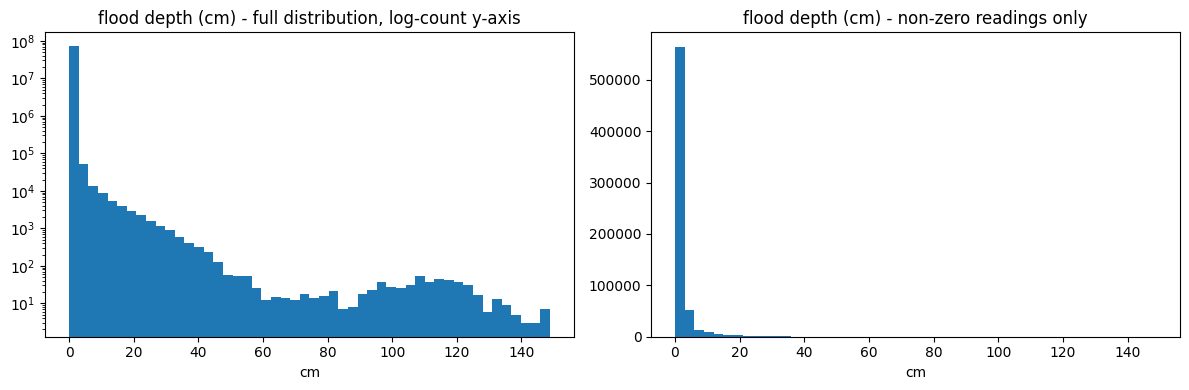

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(flood_all["flood"], bins=50)
axes[0].set_yscale("log")
axes[0].set_title("flood depth (cm) - full distribution, log-count y-axis")
axes[0].set_xlabel("cm")

axes[1].hist(nonzero, bins=50)
axes[1].set_title("flood depth (cm) - non-zero readings only")
axes[1].set_xlabel("cm")
plt.tight_layout()
plt.show()


In [13]:
# per-site summary: which sites actually see flooding, and how severe
per_site = flood_all.groupby("flood_code", observed=True)["flood"].agg(
    ["count", "mean", "max", lambda s: (s > 0).mean()]
)
per_site.columns = ["n_readings", "mean_depth", "max_depth", "frac_nonzero"]
per_site.sort_values("max_depth", ascending=False).head(15)


,n_readings,mean_depth,max_depth,frac_nonzero
flood_code,,,,
FL.CTC.05,735546,0.068479,148.800003,0.004291
FL.PYT.07,736416,0.055981,147.699997,0.001835
FL.KTY.05,736415,0.008335,139.399994,0.001146
FL.KTY.03,736416,0.004136,101.300003,0.006536
FL.BKM.01,736413,0.039694,77.500000,0.003581
FL.LSI.03,603517,0.091741,73.300003,0.115463
FL.LSI.06,736415,0.010092,67.800003,0.000819
FL.BKM.02,736409,0.023772,63.000000,0.027357
FL.WTN.01,674495,0.017714,61.500000,0.003282


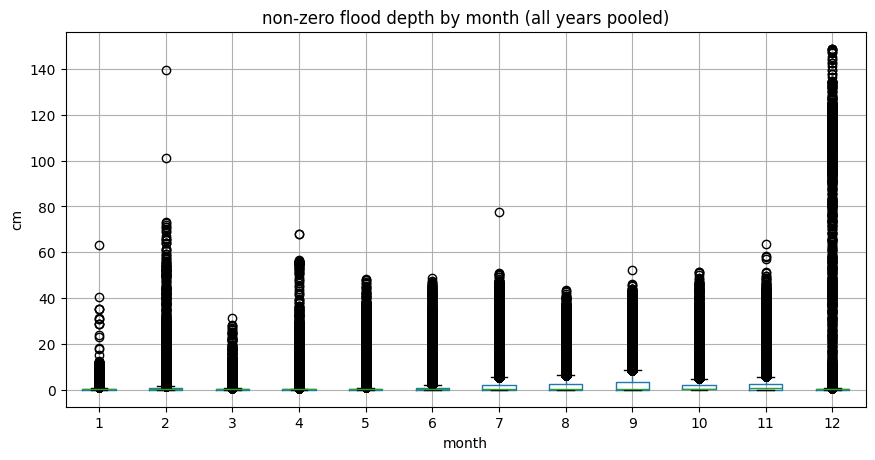

In [14]:
# monthly pattern - useful sanity check against Bangkok's wet season (roughly May-Oct)
monthly = flood_all[flood_all["flood"] > 0].boxplot(column="flood", by="month", figsize=(10, 5))
plt.title("non-zero flood depth by month (all years pooled)")
plt.suptitle("")
plt.ylabel("cm")
plt.show()


## Section D — Quick look at Flow, Rain, Water

Not the label, but these will feed the feature set, so worth a first look now rather than
discovering surprises mid feature-engineering.


In [15]:
rain_2025 = load_year("rain", 2025, usecols=["rain_code", "site_timestamp", "rf5min", "rf1hr", "rf24hr"])
print(rain_2025[["rf5min", "rf1hr", "rf24hr"]].describe())
print(f"\nzero-rf5min fraction: {(rain_2025['rf5min'] == 0).mean():.4%}")


             rf5min         rf1hr        rf24hr
count  1.329802e+07  1.329802e+07  1.329802e+07
mean   1.492155e-02  1.789841e-01  4.295014e+00
std    2.199659e-01  1.751165e+00  1.138874e+01
min    0.000000e+00  0.000000e+00  0.000000e+00
25%    0.000000e+00  0.000000e+00  0.000000e+00
50%    0.000000e+00  0.000000e+00  0.000000e+00
75%    0.000000e+00  0.000000e+00  1.500000e+00
max    2.100000e+01  1.220000e+02  1.675000e+02

zero-rf5min fraction: 95.4740%


In [16]:
flow_2025 = load_year("flow", 2025)
print(flow_2025[["flow", "wl", "area", "mean_velocity"]].describe())
print(f"\nnegative flow readings (possible reverse flow / sensor noise): {(flow_2025['flow'] < 0).sum()}")


               flow            wl          area  mean_velocity
count  2.651223e+06  2.648502e+06  2.642795e+06   2.651258e+06
mean   4.010709e+01  7.774594e-02  1.419472e+02   1.243619e-01
std    3.550111e+02  6.390214e-01  5.429337e+02   2.723167e-01
min   -3.285870e+03 -2.290000e+00  0.000000e+00  -3.900000e+00
25%    0.000000e+00 -3.100000e-01  1.800000e+01   0.000000e+00
50%    0.000000e+00  1.000000e-01  3.209000e+01   0.000000e+00
75%    5.140000e+00  5.300000e-01  6.300000e+01   2.100000e-01
max    3.801810e+03  3.600000e+00  3.268330e+03   8.560000e+00

negative flow readings (possible reverse flow / sensor noise): 41581


In [17]:
water_2025 = load_year("water", 2025)
print(water_2025[["wl_in", "wl_out01", "wl_out02"]].describe())
print("\nmissingness (NULL string -> NaN):")
water_2025[["wl_in", "wl_out01", "wl_out02"]].isna().mean().rename("frac_null")


              wl_in      wl_out01       wl_out02
count  2.869228e+07  4.993826e+06  105120.000000
mean  -3.086164e-01  3.967762e-01       0.557538
std    6.238106e-01  6.565181e-01       0.668481
min   -4.870000e+00 -2.730000e+00      -1.600000
25%   -7.000000e-01 -1.600000e-01       0.100000
50%   -3.100000e-01  4.300000e-01       0.640000
75%    1.800000e-01  8.900000e-01       1.070000
max    2.280000e+00  2.450000e+00       2.190000

missingness (NULL string -> NaN):


wl_in       0.090174
wl_out01    0.841647
wl_out02    0.996667
Name: frac_null, dtype: float64

## Section E — Findings vs. `BKK_Flood_Forecast_Technical_Roadmap_1.docx`

Section 6 of the roadmap ("Known Data Quality Findings") documents profiling results against what
it describes as "10 stations each" for rain/water/flow/flood, ~1.05M rows/file. The files actually
in `data/` are a much bigger export — **107 flood / 30 flow / 131 rain / 300 water sites**, 3.1M–
31.5M rows/file for 2025 alone. So the roadmap's findings and this data are not the same export;
treat the table below as "verified against the data actually available now," not as catching
errors in the roadmap.

| # | Roadmap finding (10-station export) | Verified here (full export, 2025, checked 2026-07-14) | Verdict |
|---|---|---|---|
| 1 | Excel 1,048,576-row ceiling truncates the last station by ~9.1 days | All 107 Flood sites have exactly 105,120 rows, ending 2025-12-31 23:55 — **no truncation** | **Resolved** for Flood 2025 (matches the roadmap's own recommendation to re-export as CSV). Re-run the Section B tail-check cell above on Flow/Rain/Water and other years before closing this out entirely — only Flood was hand-verified. |
| 2 | Flood depth range 0–33.8 cm | Range 0–61.5 cm | **Wider**, consistent with 10x more stations — not a contradiction. |
| 3 | Flood: 79.7% zero / 20.2% `"NULL"` / ~0.07% real nonzero | 89.22% zero / 10.70% `"NULL"` / 0.081% real nonzero | **Same shape** (real-flood readings are ~0.08% either way), split between zero/NULL differs. Confirms `"NULL"` string values are real and material — handle via `na_values=["NULL"]` (already done in `load_year`). |
| 4 | `wl_out01`/`wl_out02` 100% NULL, all stations, all year | `wl_out01` 84.16% NULL, `wl_out02` 99.67% NULL | **Does not hold** for the full network — some stations do populate these. Don't blanket-exclude from features; check which specific stations report before deciding. |
| 5 | Flow: 28.4% of rows have all 4 value columns null together | 15.93% | **Same direction**, smaller magnitude on the full 30-station file. "Mask the whole timestep" recommendation still applies. |
| 6 | Negative flow: 5,113 rows, down to −32.76 m³/s, read as tidal backflow, keep as-is | 41,581 negative rows (1.32%). Of those, **14,809 are below −1,000 m³/s (down to −3,285.87), all from a single station: `FW.PKG.01`** | **New finding, not in the roadmap.** −3,285 m³/s is two orders of magnitude past a plausible tidal-backflow reading. Recommend treating `FW.PKG.01`'s extreme negatives as a likely sensor/calibration fault (flag to Data/GIS engineer) separately from the smaller, more plausible negative readings elsewhere in the network, rather than blanket-accepting all negative flow as real signal. |

Row 6 is worth raising with the Data & GIS engineer specifically before Evaluation Point #9 (data
inventory) gets written up, since it changes the "keep negative flow as-is" guidance from a
blanket rule to a per-station judgment call.


In [19]:
# Reproducible version of the table above - rerun any time the underlying files change.
station_counts = {ds: int(audit.loc[audit["dataset"] == ds, "n_sites"].max()) for ds in DATASETS}
print("station counts (roadmap assumed 10 for every dataset):", station_counts)

print(f"\nflood 2025 (all {station_counts['flood']} sites):")
print(f"  zero={( flood_all['flood'] == 0 ).mean():.4%}  null={flood_all['flood'].isna().mean():.4%}  "
      f"nonzero={(flood_all['flood'] > 0).mean():.4%}  max={flood_all['flood'].max()}")
print("  roadmap (10-station export): zero=79.7% null=20.2% nonzero=~0.07% max=33.8")

print(f"\nwater wl_out01 null: {water_2025['wl_out01'].isna().mean():.4%}  (roadmap: 100%)")
print(f"water wl_out02 null: {water_2025['wl_out02'].isna().mean():.4%}  (roadmap: 100%)")

flow_cols = ["flow", "wl", "area", "mean_velocity"]
print(f"\nflow all-4-null timestep fraction: {flow_2025[flow_cols].isna().all(axis=1).mean():.4%}  (roadmap: 28.4%)")

neg = flow_2025[flow_2025["flow"] < 0]
print(f"negative flow rows: {len(neg)}  (roadmap: 5,113)")
print(f"min flow: {flow_2025['flow'].min()}  (roadmap: -32.76)")

extreme_neg = neg[neg["flow"] < -1000]
print(f"rows with flow < -1000 m3/s: {len(extreme_neg)}, stations: {extreme_neg['flow_code'].unique().tolist()}")


station counts (roadmap assumed 10 for every dataset): {'flood': 107, 'flow': 30, 'rain': 131, 'water': 300}

flood 2025 (all 107 sites):
  zero=94.1529%  null=4.9811%  nonzero=0.8659%  max=148.8000030517578
  roadmap (10-station export): zero=79.7% null=20.2% nonzero=~0.07% max=33.8

water wl_out01 null: 84.1647%  (roadmap: 100%)
water wl_out02 null: 99.6667%  (roadmap: 100%)

flow all-4-null timestep fraction: 15.9291%  (roadmap: 28.4%)
negative flow rows: 41581  (roadmap: 5,113)
min flow: -3285.8701171875  (roadmap: -32.76)
rows with flow < -1000 m3/s: 14809, stations: ['FW.PKG.01']


## Section F — Label definition: checklist to sync with the Data/GIS engineer

The roadmap already answers most of what a first-pass checklist would normally ask — good news,
less to negotiate from scratch. What's left is confirming those answers still hold given how much
bigger the actual dataset is, plus a few things the roadmap doesn't cover.

**Already decided in the roadmap (Section 5/6/9) — confirm still current, don't re-derive:**

- [ ] **Units** — `flood` is continuous depth in **cm**. Verified consistent with the full data
      (2025 range 0–61.5, wider than the roadmap's 0–33.8 but same units/shape).
- [ ] **Tiering** — roadmap's dashboard scheme: Normal <5cm, Watch 5–15cm, Warning 15–30cm,
      Critical >30cm (Section 9, CAP mapping). This is *more specific* than a generic "0/15/30"
      split — use these exact boundaries, not a re-guess.
- [ ] **Dual target** — derive both a continuous depth (regression) and the 4-tier class
      (classification) from the same `flood` column (Section 7, "dual-head target design").
- [ ] **Class imbalance handling** — roadmap already prescribes: aggregate multiple years, report
      FNR/precision/recall not accuracy, consider class weighting (Section 6 Action column). The
      verified imbalance (Section E above: ~0.08% real nonzero readings) makes this non-negotiable,
      not optional.

**Genuinely open — worth raising with the Data/GIS engineer specifically:**

- [ ] **Station-count reconciliation** — the roadmap itself uses three different station counts:
      "10 stations each" (Section 6 findings), "40 stations" to geocode (Section 10, Days 5–9), and
      the actual `data/` files have 107 flood / 30 flow / 131 rain / 300 water sites. Which of
      these defines the real modeling scope? This affects the station registry, the geocoding
      workload, and whether Section 6's findings need restating for the full network.
- [ ] **Granularity** — roadmap's classification head is described as "event probability... derived
      by thresholding the flood depth column," which reads as per-timestep thresholding rather than
      per contiguous flood episode, but isn't stated explicitly either way. Confirm.
- [ ] **`FW.PKG.01` flow outlier** (Section E above) — 14,809 rows in 2025 alone below −1,000 m³/s,
      not consistent with the "tidal backflow, keep as-is" guidance for ordinary negative flow.
      Needs a decision: exclude this station, cap/clip its readings, or confirm it's real.
- [ ] **`wl_out01`/`wl_out02`** — roadmap says 100% NULL, exclude. Full data shows 84%/99.7% NULL —
      some stations do report. Re-check per-station before excluding outright.
- [ ] **Site scope for modeling** — once station count is reconciled, are all sites in scope, or
      only ones with reliable/long-enough history? Cross-check against Section B's coverage and
      tail-truncation flags.


## Section G — Open questions / findings log

_Fill in after actually running this against the data and after the sync with the Data/GIS
engineer. Not pre-filled — this is meant to capture what changed vs. the assumptions above._
